In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import torch
import torch.nn as nn
import torchvision.models as models

(-0.5, 511.5, 247.5, -0.5)

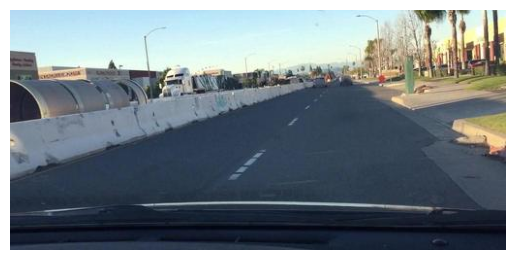

In [2]:
data_dir = "data"

files = sorted(os.listdir(data_dir))

img = Image.open(os.path.join(data_dir, files[0]))
plt.imshow(img)
plt.axis("off")

In [3]:
files[:4]

['Anaheim-0021450d.jpg',
 'Anaheim-00380032.jpg',
 'Anaheim-00752b22.jpg',
 'Anaheim-011a4d5d.jpg']

In [4]:
from collections import Counter

labels = [f.split("-")[0] for f in files]
Counter(labels)

Counter({'SLO': 1588,
         'Anaheim': 1584,
         'Riverside': 1582,
         'San_Diego': 1510,
         'Bakersfield': 1488,
         'Los_Angeles': 1429})

In [5]:
city_to_idx = {
    "Anaheim": 0,
    "Bakersfield": 1,
    "Los_Angeles": 2,
    "Riverside": 3,
    "San_Diego": 4,
    "SLO": 5
}

idx_to_city = {v: k for k, v in city_to_idx.items()}

In [6]:
class SoCalDataset(Dataset):
    
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.files = os.listdir(data_dir)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        
        filename = self.files[idx]
        img_path = os.path.join(self.data_dir, filename)

        image = Image.open(img_path).convert("RGB")

        label_name = filename.split("-")[0]
        label = city_to_idx[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = SoCalDataset("data", transform=transform)
image, label = dataset[0]


In [8]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [23]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

model.fc = nn.Linear(model.fc.in_features, 6)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

images, labels = images.to(device), labels.to(device)

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
loss = criterion(outputs, labels)

In [22]:
num_epochs = 1  # start with 1 epoch for testing

for epoch in range(num_epochs):
    model.train()  # put model in training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward pass + optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # statistics
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    print(f"Epoch {epoch+1} — Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

Epoch 1 — Loss: 0.6711, Accuracy: 0.7655


In [24]:
model.eval()  # put model in evaluation mode
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        val_correct += (outputs.argmax(dim=1) == labels).sum().item()
        val_total += images.size(0)

val_acc = val_correct / val_total
print(f"Validation Accuracy: {val_acc:.4f}")

Validation Accuracy: 0.1622


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Assume your dataset, model, criterion, optimizer, and device are already set up
# dataset: SoCalDataset with transforms
# model: ResNet18 with final layer output 6 classes
# criterion: nn.CrossEntropyLoss()
# optimizer: torch.optim.Adam(model.parameters(), lr=0.001)
# device: "cuda" if available else "cpu"

# ----------------------------
# Split dataset
# ----------------------------
VAL_FRACTION = 0.2
val_size = int(len(dataset) * VAL_FRACTION)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# ----------------------------
# Training loop
# ----------------------------
num_epochs = 5  # can increase to 10+ for better results

train_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # ----------------------------
    # Validation
    # ----------------------------
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += images.size(0)

    val_acc = val_correct / val_total
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} — "
        f"Train Loss: {epoch_loss:.4f}, "
        f"Train Acc: {epoch_acc:.4f}, "
        f"Val Acc: {val_acc:.4f}"
    )

# ----------------------------
# Save the model
# ----------------------------
torch.save(model.state_dict(), "resnet18_socal.pt")
print("Saved model as resnet18_socal.pt")

# ----------------------------
# Plot training curves
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Curves")
plt.legend()
plt.show()